In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
curr_dir_path = os.getcwd()
main_dir_path = os.path.abspath(os.path.join(curr_dir_path, os.pardir))
data_dir_path = os.path.join(main_dir_path, 'data')
raw_data_dir_path = os.path.join(data_dir_path, 'raw_data')
emissions_data_dir_path = os.path.join(raw_data_dir_path, 'emissions_data')
iea_data_dir_path = os.path.join(raw_data_dir_path, 'IEA_climate_policy_data')

In [3]:
IEA_policies_df = pd.read_csv(os.path.join(iea_data_dir_path, 'IEA_PAMS_Export 1_29_2025, 6_11_31 PM.csv'))
IEA_policies_df

,year,jurisdiction,title,description,status,ISO3,country,topic,type,category,source
0,2011.0,National,Law 47-09 on Energy Efficiency,"Law 47-09, or the ""Law on Energy Efficiency"" a...",In force,MAR,Morocco,NaN,NaN,NaN,http://www.muat.gov.ma/sites/default/files/Reg...
1,2017.0,National,Swiss Energy Strategy 2050,Swiss Energy Strategy 2050The Swiss Energy Str...,In force,CHE,Switzerland,Economy-wide,"Master Energy Plan,Framework legislation",NaN,https://www.uvek.admin.ch/uvek/de/home/energie...
2,2009.0,National,Buy Smart project,"The aim of the Buy Smart""- project is to promo...",Ended,DEU,Germany,NaN,NaN,NaN,https://www.european-energy-award.de/european-...
3,2010.0,National,A Group of Energy Efficiency Measures in Agric...,This group consists of five PAMs.1. Biomass bo...,In force,FIN,Finland,NaN,NaN,NaN,http://www.mmm.fi/en/index/frontpage.html
4,1999.0,National,New Buses,Financial assistance to regions and municipali...,In force,ITA,Italy,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
13150,1996.0,National,Voluntary Energy Audits,The Grand Ducal regulation of 11 August 1996 o...,In force,LUX,Luxembourg,NaN,NaN,NaN,NaN
13151,2008.0,National,Carbon Emissions Reduction Target (Energy Effi...,The Carbon Emissions Reduction Target (CERT) -...,Ended,GBR,United Kingdom,NaN,NaN,NaN,https://www.ofgem.gov.uk/environmental-program...
13152,2009.0,National,Saving energy by the organizations of local au...,The programmes concern the implementation of i...,Ended,GRC,Greece,NaN,NaN,NaN,NaN
13153,2006.0,National,Public Transit Capital Trust,Canada's Federal Budget 2006 dedicated CAD 1.3...,In force,CAN,Canada,NaN,NaN,NaN,NaN


## Data Integrity and Initial Cleaning

### Missing data in important columns
- year.
- iso3.

In [4]:
IEA_policies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13155 entries, 0 to 13154
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          13127 non-null  float64
 1   jurisdiction  13155 non-null  object 
 2   title         13155 non-null  object 
 3   description   13119 non-null  object 
 4   status        13155 non-null  object 
 5   ISO3          13149 non-null  object 
 6   country       13155 non-null  object 
 7   topic         7046 non-null   object 
 8   type          7046 non-null   object 
 9   category      3630 non-null   object 
 10  source        12083 non-null  object 
dtypes: float64(1), object(10)
memory usage: 1.1+ MB


In [5]:
# Check for duplicates
duplicates = IEA_policies_df.duplicated()
duplicates.value_counts()

False    12742
True       413
Name: count, dtype: int64

In [6]:
# Eliminate duplicates
IEA_policies_df = IEA_policies_df.drop_duplicates()

In [7]:
# Check for NaN in year column
IEA_policies_df['year'].isnull().value_counts()

year
False    12715
True        27
Name: count, dtype: int64

In [8]:
# Print null cols where year is null
# IEA_policies_df[IEA_policies_df['year'].isnull()]

In [9]:
# For now let's drop the rows with NaN in year column
IEA_policies_df = IEA_policies_df.dropna(subset=['year'])

In [10]:
# Check for NaN in iso3 column
IEA_policies_df['ISO3'].isnull().value_counts()

ISO3
False    12710
True         5
Name: count, dtype: int64

In [11]:
IEA_policies_df[IEA_policies_df['ISO3'].isnull()]

,year,jurisdiction,title,description,status,ISO3,country,topic,type,category,source
226,2013.0,International,Climate Technology Centre and Network Technica...,The Climate Technology Centre and Network (CTC...,In force,NaN,Unknown,NaN,NaN,NaN,https://www.ctc-n.org/technical-assistance
229,2009.0,International,The World Bank Carbon Capture and Storage Capa...,"The World Bank CCS Trust Fund, established in ...",In force,NaN,Unknown,NaN,NaN,NaN,http://www.zeroco2.no/projects/world-bank-ccs-...
3325,2015.0,International,The Vatican’s Laudato Si’ Action Platform,Pope Francis issued the Laudato Si’ encyclical...,In force,NaN,Vatican City,People-Centred Clean Energy Transitions,"Socioeconomic development,,Public participation,",NaN,https://laudatosiactionplatform.org/about/
3342,2008.0,National,Vatican installation of PV system,"To help green its operations, as promoted by P...",In force,NaN,Vatican City,People-Centred Clean Energy Transitions,"Energy security and resilience,,Public partici...",NaN,https://www.baywa-re.com/en/cases/emea/high-te...
5019,2019.0,International,LEAP-RE,LEAP-RE is a mechanism for funding R&amp;D and...,In force,NaN,African Union,Technology R&D and innovation,"Grants,Resource push",Grants for R&D projects,https://www.leap-re.eu/


In [12]:
# Drop rows with NaN in iso3 column
IEA_policies_df = IEA_policies_df.dropna(subset=['ISO3'])

## Understanding the Data

- Num of regions: 217


In [13]:
# How many countries we have?
IEA_policies_df['country'].unique()

array(['Morocco', 'Switzerland', 'Germany', 'Finland', 'Italy', 'Greece',
       'Netherlands', "People's Republic of China", 'Turkiye', 'France',
       'United States', 'New Zealand', 'Canada', 'Norway', 'Spain',
       'Luxembourg', 'Sweden', 'Australia', 'European Union',
       'United Arab Emirates', 'United Kingdom', 'Portugal', 'Tunisia',
       'Brazil', 'Korea', 'Hungary', 'Japan', 'Russian Federation',
       'Denmark', 'Czechia', 'Turkmenistan', 'Singapore', 'India',
       'Belgium', 'Lithuania', 'Poland', 'Ireland', 'Mexico', 'Viet Nam',
       'Bolivarian Republic of Venezuela', 'Argentina', 'Israel',
       'Ukraine', 'Costa Rica', 'Peru', 'Jordan', 'Malaysia', 'Uruguay',
       'Saudi Arabia', 'Ghana', 'Pakistan', 'Belarus', 'Panama',
       'Tajikistan', 'Armenia', 'Barbados', 'Kenya', 'Nigeria', 'Iceland',
       'Mauritius', 'Zimbabwe', 'Azerbaijan', 'Philippines', 'Angola',
       'Ethiopia', 'Namibia', 'Jamaica', 'Afghanistan', 'Bahrain',
       'Benin', 'Banglade

In [ ]:
# Print the amount of countries
len(IEA_policies_df['country'].unique())

217

In [ ]:
# How many policies each country has?
policies_per_country_df = IEA_policies_df['ISO3'].value_counts().reset_index()
policies_per_country_df.columns = ['country', 'policy_count']
policies_per_country_df



,country,policy_count
0,United States,760
1,Australia,469
2,Canada,436
3,People's Republic of China,397
4,United Kingdom,347
...,...,...
212,British Indian Ocean Territory,1
213,Netherlands Antilles,1
214,French Guiana,1
215,Western Sahara,1


In [24]:
# Add max year and min year for each country
max_year_per_country = IEA_policies_df.groupby('country')['year'].max().reset_index()
min_year_per_country = IEA_policies_df.groupby('country')['year'].min().reset_index()
max_year_per_country.columns = ['country', 'max_year']
min_year_per_country.columns = ['country', 'min_year']


In [25]:
max_year_per_country.head()

,country,max_year
0,Afghanistan,2021.0
1,Albania,2022.0
2,Algeria,2024.0
3,Andorra,2021.0
4,Angola,2024.0


In [26]:
min_year_per_country.head()

,country,min_year
0,Afghanistan,1971.0
1,Albania,1976.0
2,Algeria,1976.0
3,Andorra,1987.0
4,Angola,1971.0


In [27]:
# merge max year and min year with policies_per_country_df
policies_per_country_df = policies_per_country_df.merge(max_year_per_country, on='country')
policies_per_country_df = policies_per_country_df.merge(min_year_per_country, on='country')
policies_per_country_df

,country,policy_count,max_year,min_year
0,United States,760,2027.0,1970.0
1,Australia,469,2025.0,1970.0
2,Canada,436,2026.0,1971.0
3,People's Republic of China,397,2025.0,1986.0
4,United Kingdom,347,2025.0,1976.0
...,...,...,...,...
212,British Indian Ocean Territory,1,2014.0,2014.0
213,Netherlands Antilles,1,2014.0,2014.0
214,French Guiana,1,1994.0,1994.0
215,Western Sahara,1,2019.0,2019.0


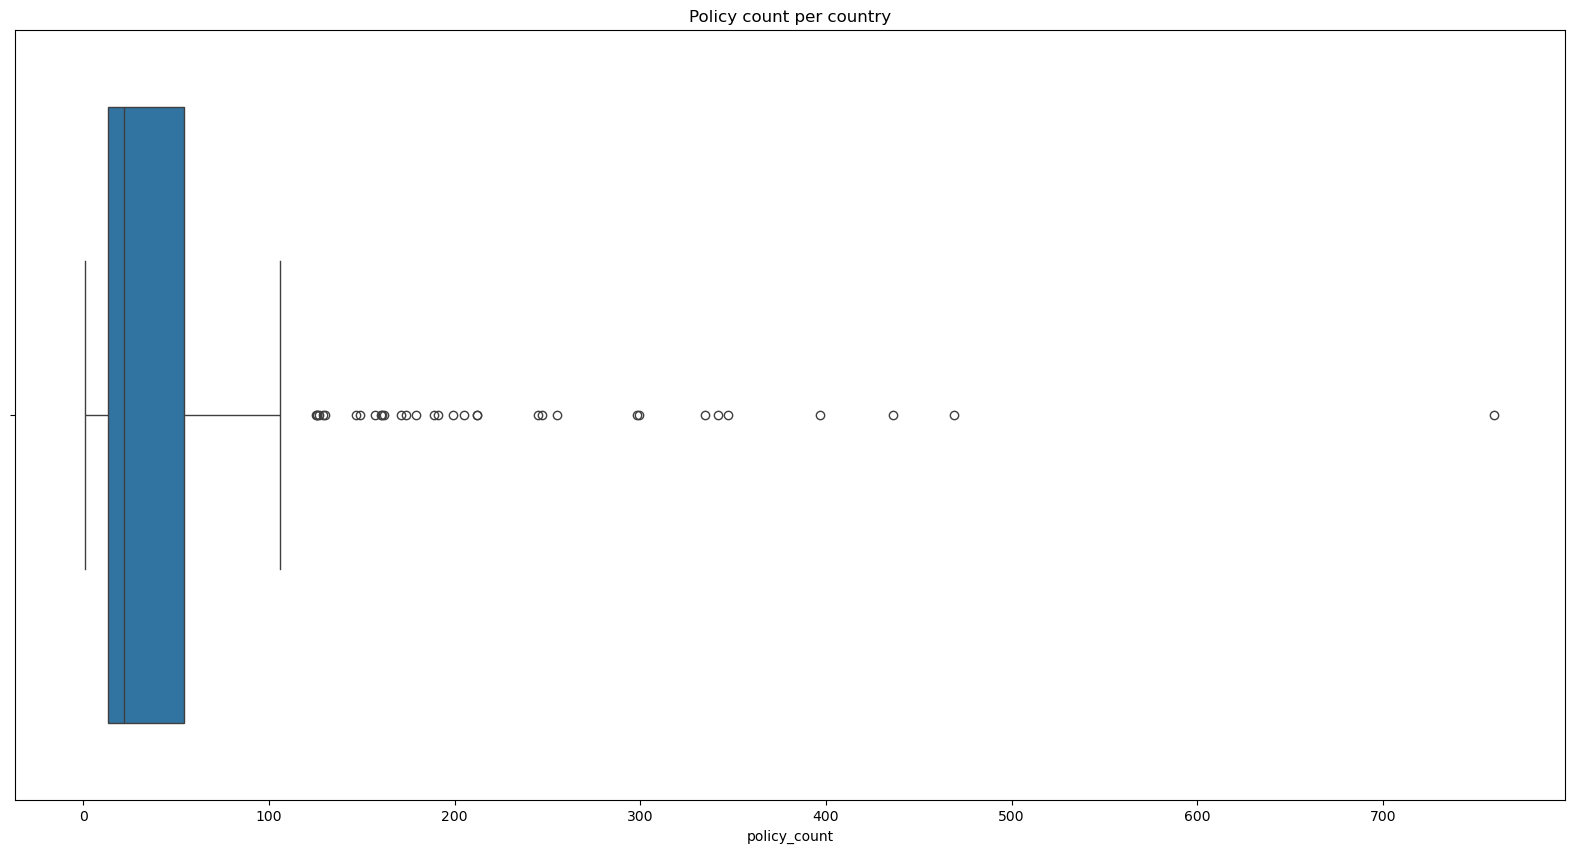

In [31]:
# Boxplot of policy count per country
plt.figure(figsize=(20, 10))
sns.boxplot(data=policies_per_country_df, x='policy_count')
plt.title('Policy count per country')
plt.show()

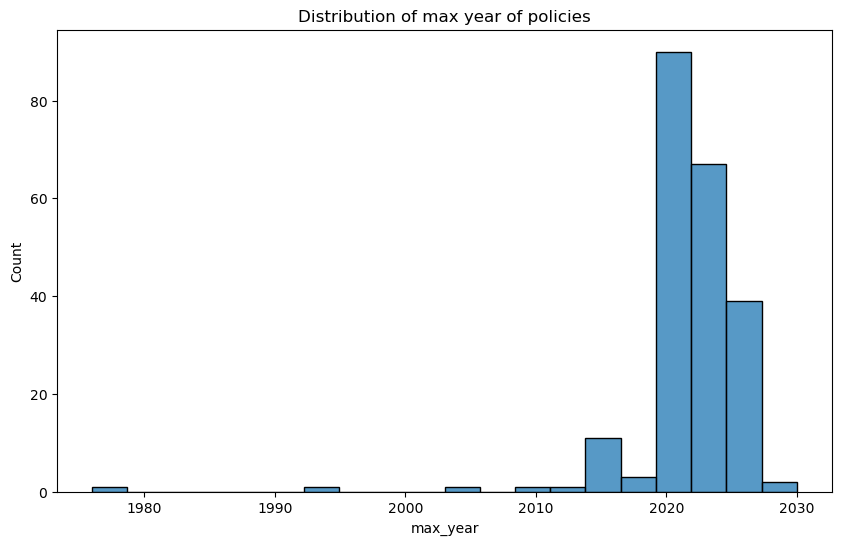

In [29]:
# Plot distribution of max_year
plt.figure(figsize=(10, 6))
sns.histplot(policies_per_country_df['max_year'], bins=20)
plt.title('Distribution of max year of policies')
plt.show()

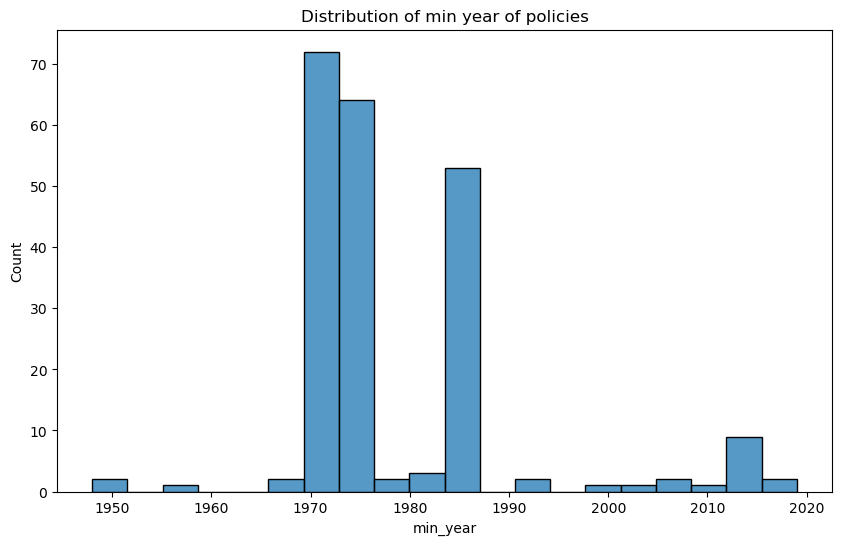

In [30]:
# Plot distribution of min_year
plt.figure(figsize=(10, 6))
sns.histplot(policies_per_country_df['min_year'], bins=20)
plt.title('Distribution of min year of policies')
plt.show()

In [32]:
IEA_policies_df.columns

Index(['year', 'jurisdiction', 'title', 'description', 'status', 'ISO3',
       'country', 'topic', 'type', 'category', 'source'],
      dtype='object')

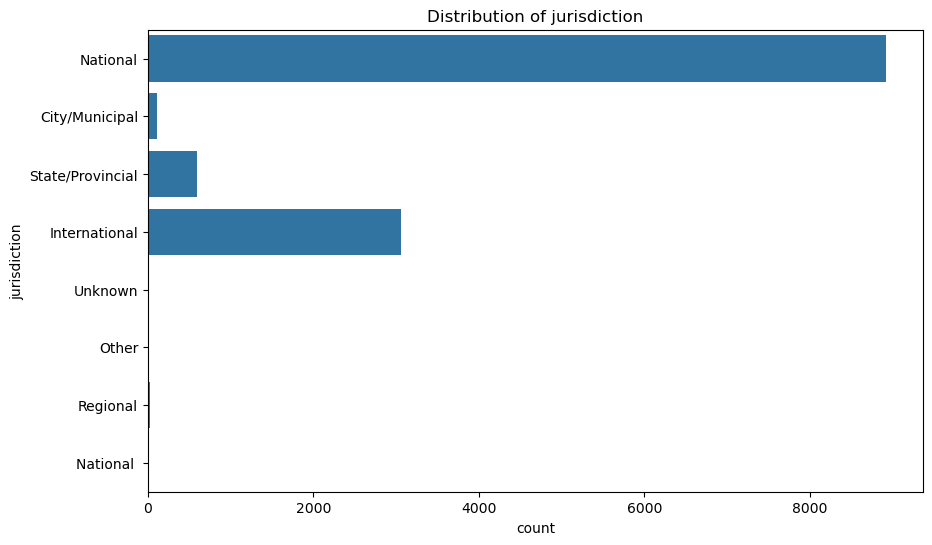

In [33]:
# Plot distribution of jurisdiction
plt.figure(figsize=(10, 6))
sns.countplot(data=IEA_policies_df, y='jurisdiction')
plt.title('Distribution of jurisdiction')
plt.show()

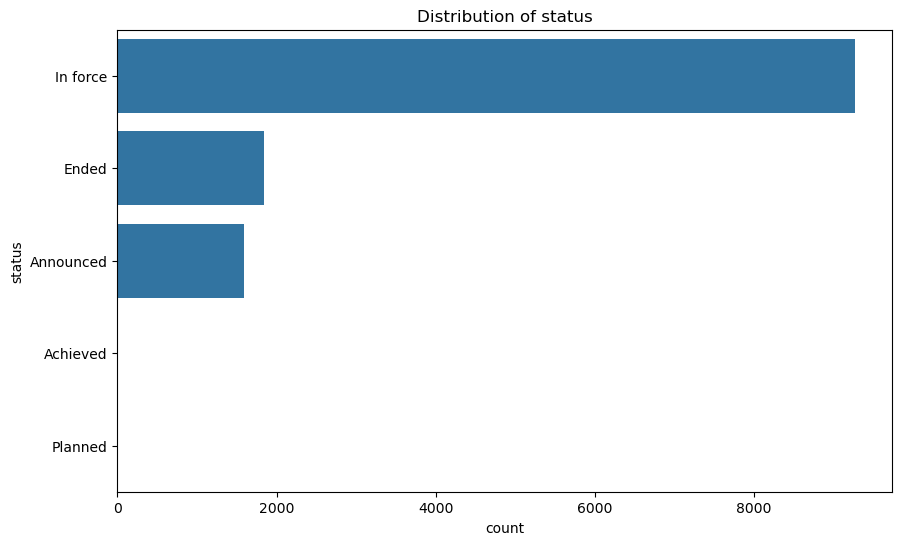

In [34]:
# Plot distribution of status
plt.figure(figsize=(10, 6))
sns.countplot(data=IEA_policies_df, y='status')
plt.title('Distribution of status')
plt.show()
